# Travel Insurance: Mitigating Liquidity Risk Using Machine Learning to Predict Insurance Claim Submission
### Created by: Muhammad Rafie Darmawan

## Business Understanding

**Understanding The Business in General**  
Sebuah perusahaan Asuransi Travel XYZ memberikan sebuah layanan asuransi untuk traveler yang ingin bepergian secara tenang untuk perjalanan domestik dan luar negeri. Beberapa negara mewajibkan traveler yang akan berkunjung untuk memiliki asuransi travel, terkhususnya negara-negara di Amerika dan Eropa.

**Problem in Business**  
Memitigasi risiko liquiditas keuangan di mana perusahaan harus menyiapkan alokasi untuk traveler yang akan klaim asuransi dapat menjadi sebuah issue apabila perusahaan buta terhadap kemungkinan jumlah customers yang akan klaim asuransi. Bilamana perusahaan tidak menyiapkan alokasi yang cukup dan terjadi lonjakan dalam konteks jumlah traveler yang klaim asuransi yang melebihi ekspektasi perusahaan, perusahaan bisa berada dalam risiko tidak bisa memenuhi klaim asuransi tersebut.

**Objective**  
Karena itulah, perusahaan Asuransi Travel XYZ berekspektasi untuk bisa memprediksi traveler yang akan klaim asuransi, supaya perusahaan memiliki gambaran (setidaknya gambaran kasar) untuk menentukan alokasi keuangan mereka.

**Analytical Approach based on Data**  
Target (Label):  
0: Traveler that did not claim insurance  
1: Traveler that claimed insurance  
  
Target di atas merupakan _expected output_ yang perusahaan ingin prediksi, dan pendekatan menggunakan model classification merupakan pendekatan terbaik untuk memprediksi target output tersebut.  


## Brief Data Understanding  

**Metric Evaluation**  
Pembuatan model _is a one thing_. Saat model tersebut telah ada, kita harus mengevaluasi hasil prediksi yang dihasilkan, dan hal tersebut dapat dilakukan melalui _metric evaluation_.  

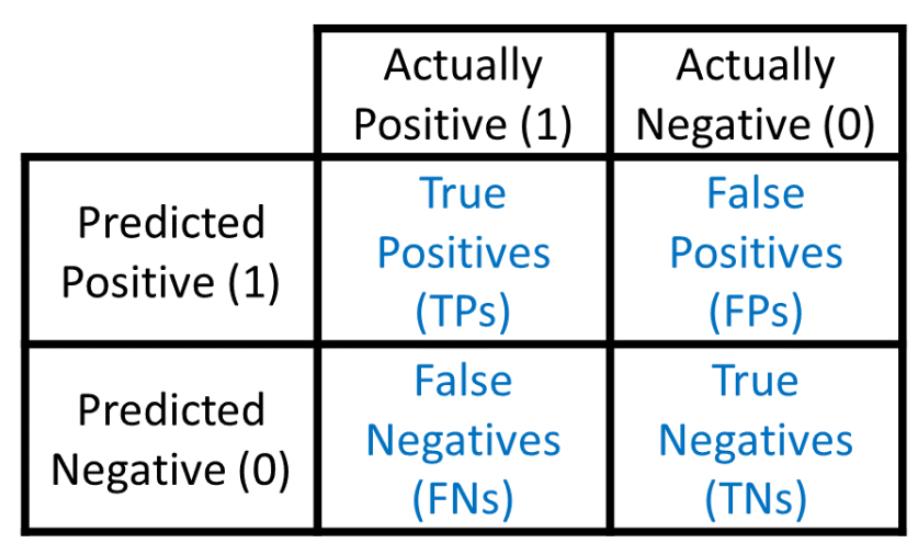

Confusion Matrix di atas menunjukkan metric yang ingin kita fokuskan menjadi metric utama untuk menentukan performa model, dan error yang ingin kita hindari dalam konteks bisnis.  
Berikut adalah tipe error yang bisa terjadi serta business impact-nya:  
  
- Type 1 Error: False Positive  
Business impact: Budget reserved yang tidak dibutuhkan, premi yang _overpriced_, customers _churn_

- Type 2 Error: False Negative
Business impact: Direct financial loss dari segi kesiapan budget yang di-reserved, premi yang _underpriced_, risiko liquiditas  

Pada model machine learning, **kebanyakan** case dalam error pada metric evaluation yang ingin dihindari adalah type 2 error, karena _basically_ model gagal memprediksi customer yang melakukan output _positif_. Pada konteks asuransi travel pun, case yang sama terjadi, karena business impact dari type 2 error jauh lebih besar resiko nya dibanding dengan type 2 error. Karena itulah, metric utama yang akan kita gunakan sebagai baseline evaluasi adalah metric _RECALL_ atau disebut juga _TRUE POSITIVE RATE_.    

**Potential Imbalanced Data**   
Jumlah data yang tidak seimbang pada tiap kelasnya (positif: klaim asuransi, negatif: tidak klaim asuransi) dengan persentase 1.53% class positive (minority class) dapat menyebabkan issue terhadap metric recall yang menjadi metric evaluasi kita. Karena itu, kita juga akan menggunakan metric _PRECISION-RECALL (PR) CURVE_ untuk melihat trade-off dari metric recall yang kita fokuskan.

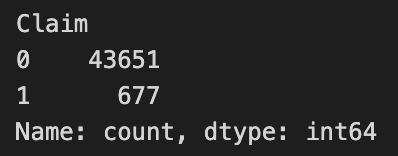

### Dataset Understanding

| Attribute | Data Type, Length | Description |
| --- | --- | --- |
| Agency | object | Agency code |
| Agency Type | object | Type of travel insurance agencies |
| Distribution Channel | object | Channel of travel insurance agencies |
| Product Name | object | Name of the travel insurance products |
| Gender | object | Gender of insured |
| Duration | INT | Duration of travel |
| Destination | object | Destination of travel |
| Net Sales | float | Amount of sales of travel insurance policies |
| Commision (in value) | float | Commission received for travel insurance agency |
| Age | INT | Insured's age |
| Claim | object | Not claimed, Claimed (target) |

Dari fitur-fitur yang telah tersedia pada dataset, beberapa fitur mungkin tidak akan digunakan untuk mencari pola pada machine learning karena satu dan lain hal, di antaranya:
- Gender (karena kita tidak mau mendiskriminasi kemungkinan gender yang kemungkinan lebih besar mengklaim asuransi)
- Dan beberapa di antaranya saat pengecekan data

### Library

In [690]:
# Library
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
from IPython.display import display

# Feature Engineering
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler, RobustScaler, PolynomialFeatures
from category_encoders import BinaryEncoder
from sklearn.compose import ColumnTransformer
import category_encoders as ce

# Model Selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
## ROC AUC untuk precision focused (type 1 error)
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
## PR AUC untuk recall focused (type 2 error)
from sklearn.metrics import precision_recall_curve, average_precision_score, auc, PrecisionRecallDisplay

# Pipeline
from imblearn.pipeline import Pipeline

# Imbalance Dataset
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)

### Set the data

In [691]:
df_ins = pd.read_csv("data_travel_insurance.csv")

In [692]:
df_ins

,Agency,Agency Type,Distribution Channel,Product Name,Gender,Duration,Destination,Net Sales,Commision (in value),Age,Claim
0,C2B,Airlines,Online,Annual Silver Plan,F,365,SINGAPORE,216.0,54.00,57,No
1,EPX,Travel Agency,Online,Cancellation Plan,NaN,4,MALAYSIA,10.0,0.00,33,No
2,JZI,Airlines,Online,Basic Plan,M,19,INDIA,22.0,7.70,26,No
3,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,20,UNITED STATES,112.0,0.00,59,No
4,C2B,Airlines,Online,Bronze Plan,M,8,SINGAPORE,16.0,4.00,28,No
...,...,...,...,...,...,...,...,...,...,...,...
44323,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,14,CHINA,30.0,0.00,36,Yes
44324,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,NaN,17,AUSTRALIA,79.2,47.52,47,No
44325,TST,Travel Agency,Offline,Travel Cruise Protect,M,64,THAILAND,30.0,10.50,50,No
44326,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,51,CHINA,36.0,0.00,36,No


In [693]:
df_ins["Gender"].unique()

array(['F', nan, 'M'], dtype=object)

Terdapat NULL data pada gender, tapi kita tidak akan meng-impute data tersebut karena fitur ini tidak digunakan untuk model.

In [694]:
df_ins["Agency"].unique()

array(['C2B', 'EPX', 'JZI', 'CWT', 'LWC', 'ART', 'CSR', 'SSI', 'RAB',
       'KML', 'TST', 'TTW', 'JWT', 'ADM', 'CCR', 'CBH'], dtype=object)

In [695]:
df_ins["Agency"].value_counts()

Agency
EPX    24656
CWT     5980
C2B     5753
JZI     4433
SSI      765
JWT      522
RAB      513
LWC      455
TST      354
KML      281
ART      229
CCR      126
TTW       69
CBH       69
CSR       68
ADM       55
Name: count, dtype: int64

Fitur agency akan di-drop, karena fitur ini berkemungkinan memberikan hasil yang tidak optimal pada machine learning (overfit/underfit) akibat dari sebaran data yang dimiliki pada tiap agency nya.

In [696]:
df_ins["Distribution Channel"].unique()

array(['Online', 'Offline'], dtype=object)

In [697]:
df_ins["Agency Type"].unique()

array(['Airlines', 'Travel Agency'], dtype=object)

In [698]:
df_ins["Product Name"].value_counts()

Product Name
Cancellation Plan                       12979
2 way Comprehensive Plan                 9341
Rental Vehicle Excess Insurance          5980
Basic Plan                               3834
Bronze Plan                              2847
1 way Comprehensive Plan                 2336
Value Plan                               1907
Silver Plan                              1552
Annual Silver Plan                        975
Ticket Protector                          765
Travel Cruise Protect                     353
Comprehensive Plan                        253
Gold Plan                                 237
24 Protect                                172
Annual Gold Plan                          142
Single Trip Travel Protect Gold           135
Premier Plan                              130
Single Trip Travel Protect Silver         117
Annual Travel Protect Gold                 63
Annual Travel Protect Silver               59
Individual Comprehensive Plan              48
Single Trip Travel Pr

Sama seperti fitur agency. Fitur product name juga akan di-drop, akan tetapi product name ini akan di-grouping berdasarkan plan nya yang tersedia secara semantik agar sebaran data nya tidak skewed terhadap beberapa product name.

In [699]:
plan_mapping = {    
    # Silver Group
    'Silver Plan': 'Silver Plans',
    'Annual Silver Plan': 'Silver Plans',
    'Single Trip Travel Protect Silver': 'Silver Plans',
    'Annual Travel Protect Silver': 'Silver Plans',
    
    # Gold Group
    'Gold Plan': 'Premium Tier Plans (Gold and Platinum)',
    'Annual Gold Plan': 'Premium Tier Plans (Gold and Platinum)',
    'Single Trip Travel Protect Gold': 'Premium Tier Plans (Gold and Platinum)',
    'Annual Travel Protect Gold': 'Premium Tier Plans (Gold and Platinum)',
    'Single Trip Travel Protect Platinum': 'Premium Tier Plans (Gold and Platinum)',
    'Annual Travel Protect Platinum': 'Premium Tier Plans (Gold and Platinum)',
    
    # Specialty Plans Group
    'Comprehensive Plan': 'Specialty Plans',
    'Individual Comprehensive Plan': 'Specialty Plans',
    'Spouse or Parents Comprehensive Plan': 'Specialty Plans',
    'Child Comprehensive Plan': 'Specialty Plans',
    'Travel Cruise Protect': 'Specialty Plans',
    'Travel Cruise Protect Family': 'Specialty Plans',
    '24 Protect': 'Specialty Plans',
    'Premier Plan': 'Specialty Plans'
}

df_ins['Product_Group'] = df_ins['Product Name'].replace(plan_mapping)


In [700]:
df_ins["Product_Group"].value_counts()

Product_Group
Cancellation Plan                         12979
2 way Comprehensive Plan                   9341
Rental Vehicle Excess Insurance            5980
Basic Plan                                 3834
Bronze Plan                                2847
Silver Plans                               2703
1 way Comprehensive Plan                   2336
Value Plan                                 1907
Specialty Plans                             978
Ticket Protector                            765
Premium Tier Plans (Gold and Platinum)      658
Name: count, dtype: int64

In [701]:
regions_dict = {
    'Southeast Asia': [
        'SINGAPORE', 'MALAYSIA', 'THAILAND', 'INDONESIA', 'VIET NAM', 'PHILIPPINES', 
        'BRUNEI DARUSSALAM', 'MYANMAR', 'CAMBODIA', "LAO PEOPLE'S DEMOCRATIC REPUBLIC"
    ],
    'Southern Asia': [
        'INDIA', 'SRI LANKA', 'IRAN, ISLAMIC REPUBLIC OF', 'PAKISTAN', 'NEPAL', 
        'BANGLADESH', 'MALDIVES', 'BHUTAN'
    ],
    'Eastern Asia': [
        'KOREA, REPUBLIC OF', 'JAPAN', 'HONG KONG', 'MACAO', 'CHINA', 
        'TAIWAN, PROVINCE OF CHINA', 'MONGOLIA', 'TIBET', "KOREA, DEMOCRATIC PEOPLE'S REPUBLIC OF"
    ],
    'Western Asia': [
        'UNITED ARAB EMIRATES', 'OMAN', 'TURKEY', 'QATAR', 'ISRAEL', 'SAUDI ARABIA', 
        'BAHRAIN', 'JORDAN', 'CYPRUS', 'LEBANON', 'KUWAIT', 'AZERBAIJAN', 'GEORGIA', 'ARMENIA'
    ],
    'Central Asia': [
        'TURKMENISTAN', 'KAZAKHSTAN', 'UZBEKISTAN', 'KYRGYZSTAN', 'TAJIKISTAN'
    ],
    'Northern America': [
        'UNITED STATES', 'CANADA', 'BERMUDA'
    ],
    'Central America': [
        'MEXICO', 'PANAMA', 'COSTA RICA'
    ],
    'Caribbean': [
        'CAYMAN ISLANDS', 'TRINIDAD AND TOBAGO', 'JAMAICA', 'GUADELOUPE', 
        'PUERTO RICO', 'DOMINICAN REPUBLIC'
    ],
    'South America': [
        'ARGENTINA', 'PERU', 'BRAZIL', 'VENEZUELA', 'ECUADOR', 'CHILE', 
        'COLOMBIA', 'URUGUAY', 'BOLIVIA', 'GUYANA'
    ],
    'Northern Europe': [
        'FINLAND', 'UNITED KINGDOM', 'DENMARK', 'SWEDEN', 'NORWAY', 'ESTONIA', 
        'ICELAND', 'IRELAND', 'LATVIA', 'LITHUANIA', 'FAROE ISLANDS'
    ],
    'Western Europe': [
        'GERMANY', 'BELGIUM', 'SWITZERLAND', 'NETHERLANDS', 'FRANCE', 'LUXEMBOURG', 'AUSTRIA'
    ],
    'Eastern Europe': [
        'POLAND', 'CZECH REPUBLIC', 'RUSSIAN FEDERATION', 'UKRAINE', 'HUNGARY', 
        'BELARUS', 'BULGARIA', 'ROMANIA', 'MOLDOVA, REPUBLIC OF'
    ],
    'Southern Europe': [
        'SPAIN', 'GREECE', 'SERBIA', 'ITALY', 'CROATIA', 'MALTA', 'PORTUGAL', 
        'MACEDONIA, THE FORMER YUGOSLAV REPUBLIC OF', 'SLOVENIA', 'REPUBLIC OF MONTENEGRO'
    ],
    'Northern Africa': [
        'TUNISIA', 'EGYPT', 'MOROCCO'
    ],
    'Western Africa': [
        'MALI', 'SENEGAL', 'GUINEA', 'GHANA', 'GUINEA-BISSAU', 'BENIN', 'NIGERIA'
    ],
    'Middle Africa': [
        'ANGOLA', 'CAMEROON'
    ],
    'Eastern Africa': [
        'KENYA', 'TANZANIA, UNITED REPUBLIC OF', 'ETHIOPIA', 'MAURITIUS', 
        'ZIMBABWE', 'UGANDA', 'RWANDA', 'ZAMBIA', 'REUNION'
    ],
    'Southern Africa': [
        'SOUTH AFRICA', 'NAMIBIA', 'BOTSWANA'
    ],
    'Australia and New Zealand': [
        'AUSTRALIA', 'NEW ZEALAND'
    ],
    'Melanesia': [
        'FIJI', 'PAPUA NEW GUINEA', 'VANUATU'
    ],
    'Polynesia': [
        'FRENCH POLYNESIA', 'SAMOA'
    ],
    'Micronesia': [
        'NORTHERN MARIANA ISLANDS', 'GUAM'
    ]
}

country_to_region = {
    country: region 
    for region, countries in regions_dict.items() 
    for country in countries
}

df_ins['Sub_Continent'] = df_ins['Destination'].map(country_to_region)


Dikarenakan data pada fitur destination yang sangat granular, machine learning berpotensi tidak akan menemukan pola dari data tersebut. Karena itulah, fitur destination akan di-drop, dan sebaliknya akan dibuat fitur sub continent dari tiap destination untuk membuat data yang ada tidak begitu granular.

In [702]:
df_ins.loc[df_ins["Sub_Continent"] == "Southeast Asia", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Eastern Asia", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Southeast Asia", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Southern Asia", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Western Asia", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Southern Africa", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Eastern Africa", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Northern Africa", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Central Asia", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Melanesia", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Western Africa", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Caribbean", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Micronesia", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Middle Africa", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Polynesia", "is_mandatory_travel_insurance"] = 0
df_ins.loc[df_ins["Sub_Continent"] == "Australia and New Zealand", "is_mandatory_travel_insurance"] = 1
df_ins.loc[df_ins["Sub_Continent"] == "Northern America", "is_mandatory_travel_insurance"] = 1
df_ins.loc[df_ins["Sub_Continent"] == "Northern Europe", "is_mandatory_travel_insurance"] = 1
df_ins.loc[df_ins["Sub_Continent"] == "Western Europe", "is_mandatory_travel_insurance"] = 1
df_ins.loc[df_ins["Sub_Continent"] == "Southern Europe", "is_mandatory_travel_insurance"] = 1
df_ins.loc[df_ins["Sub_Continent"] == "Eastern Europe", "is_mandatory_travel_insurance"] = 1
df_ins.loc[df_ins["Sub_Continent"] == "South America", "is_mandatory_travel_insurance"] = 1
df_ins.loc[df_ins["Sub_Continent"] == "Central America", "is_mandatory_travel_insurance"] = 1

Beberapa negara seperti negara Eropa, Amerika, dan (dengan asumsi sendiri) negara seperti Australia dan New Zealand mewajibkan turis untuk memiliki travel insurance, menjadikan orang-orang yang pergi ke destinasi tersebut berpotensi lebih besar untuk klaim asuransi. Karena itulah dibuat fitur "is_mandatory_travel_insurance" agar Machine Learning dapat menangkap pola tersebut.

In [703]:
age_group = {
    'Gen Z and Gen Alpha and after': [
        0,
        1,
        2,
        3,
        4,
        5,
        7,
        8,
        9,
        10,
        11,
        12,
        13,
        14,
        15,
        16,
        17,
        18,
        19,
        20,
        21,
        22,
        23,
        24,
        25,
        26,
        27,
        28,
        29
    ],
    'Millenial': [
        30,
        31,
        32,
        33,
        34,
        35,
        36,
        37,
        38,
        39,
        40,
        41,
        42,
        43,
        44,
        45
    ],
    'Gen X and Boomer and before': [
        46,
        47,
        48,
        49,
        50,
        51,
        52,
        53,
        54,
        55,
        56,
        57,
        58,
        59,
        60,
        61,
        62,
        63,
        64,
        65,
        66,
        67,
        68,
        69,
        70,
        71,
        72,
        73,
        74,
        75,
        76,
        77,
        78,
        79,
        80,
        81,
        82,
        83,
        84,
        85,
        86,
        87,
        88,
        118
    ]
}

age_to_age_group = {
    generation: age_group
    for age_group, age_list in age_group.items() 
    for generation in age_list
}

df_ins['Age_group'] = df_ins['Age'].map(age_to_age_group)

Seperti halnya fitur product name dan destination, fitur age di sini juga akan di-grouping berdasarkan generasinya.

In [704]:
df_ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44328 entries, 0 to 44327
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Agency                         44328 non-null  object 
 1   Agency Type                    44328 non-null  object 
 2   Distribution Channel           44328 non-null  object 
 3   Product Name                   44328 non-null  object 
 4   Gender                         12681 non-null  object 
 5   Duration                       44328 non-null  int64  
 6   Destination                    44328 non-null  object 
 7   Net Sales                      44328 non-null  float64
 8   Commision (in value)           44328 non-null  float64
 9   Age                            44328 non-null  int64  
 10  Claim                          44328 non-null  object 
 11  Product_Group                  44328 non-null  object 
 12  Sub_Continent                  44328 non-null 

In [705]:
df_ins['Claim'].value_counts()

Claim
No     43651
Yes      677
Name: count, dtype: int64

In [706]:
df_ins['Age_group'].value_counts()

Age_group
Millenial                        28980
Gen X and Boomer and before       9891
Gen Z and Gen Alpha and after     5457
Name: count, dtype: int64

In [707]:
df_ins.head(2)

,Agency,Agency Type,Distribution Channel,Product Name,Gender,Duration,Destination,Net Sales,Commision (in value),Age,Claim,Product_Group,Sub_Continent,is_mandatory_travel_insurance,Age_group
0,C2B,Airlines,Online,Annual Silver Plan,F,365,SINGAPORE,216.0,54.0,57,No,Silver Plans,Southeast Asia,0.0,Gen X and Boomer and before
1,EPX,Travel Agency,Online,Cancellation Plan,NaN,4,MALAYSIA,10.0,0.0,33,No,Cancellation Plan,Southeast Asia,0.0,Millenial


In [708]:
df_ins.loc[df_ins["Claim"] == "No", "Claim"] = 0
df_ins.loc[df_ins["Claim"] == "Yes", "Claim"] = 1

df_ins["Claim"] = df_ins["Claim"].astype("int64")

In [709]:
df_ins["net_revenue"] = df_ins["Net Sales"]-df_ins["Commision (in value)"]

In [710]:
categorical_cols = [
    "Agency Type",
    "Distribution Channel",
    "Product_Group",
    "Sub_Continent",
    "Age_group"
]

numerical_cols = [
    "Duration",
    "Net Sales",
    "Commision (in value)",
    "is_mandatory_travel_insurance",
    "net_revenue"
]

label_claim = ["Claim"]

In [711]:
necessary_cols = categorical_cols + numerical_cols + label_claim
df_ins_cleaned = df_ins[necessary_cols]

In [712]:
# df_ins_cleaned['Duration_eqfreq'] = pd.qcut(df_ins_cleaned['Duration'],4)
# df_ins_cleaned['Duration_eqfreq_encode'] = pd.qcut(df_ins_cleaned['Duration'],4, labels = range(1,5)).astype("int64")

# df_ins_cleaned['Net Sales_eqfreq'] = pd.qcut(df_ins_cleaned['Net Sales'],4)
# df_ins_cleaned['Net Sales_freq_encode'] = pd.qcut(df_ins_cleaned['Net Sales'],4, labels = range(1,5)).astype("int64")

# df_ins_cleaned['Commision (in value)_eqfreq'] = pd.qcut(df_ins_cleaned['Commision (in value)'].rank(method='first'), q =4)
# df_ins_cleaned['Commision (in value)_eqfreq_encode'] = pd.qcut(df_ins_cleaned['Commision (in value)'].rank(method='first'), q= 4, labels = range(1,5)).astype("int64")

In [713]:
# eqfreq = df_ins_cleaned.pivot_table(
#     index = 'Duration_eqfreq',
#     aggfunc = len,
#     values='Duration')
# eqfreq.columns = ['freq']
# eqfreq

In [714]:
# eqfreq = df_ins_cleaned.pivot_table(
#     index = 'Net Sales_eqfreq',
#     aggfunc = len,
#     values='Net Sales')
# eqfreq.columns = ['freq']
# eqfreq

In [715]:
# eqfreq = df_ins_cleaned.pivot_table(
#     index = 'Commision (in value)_eqfreq',
#     aggfunc = len,
#     values='Commision (in value)')
# eqfreq.columns = ['freq']
# eqfreq

In [716]:
df_ins_cleaned.head(4)

,Agency Type,Distribution Channel,Product_Group,Sub_Continent,Age_group,Duration,Net Sales,Commision (in value),is_mandatory_travel_insurance,net_revenue,Claim
0,Airlines,Online,Silver Plans,Southeast Asia,Gen X and Boomer and before,365,216.0,54.0,0.0,162.0,0
1,Travel Agency,Online,Cancellation Plan,Southeast Asia,Millenial,4,10.0,0.0,0.0,10.0,0
2,Airlines,Online,Basic Plan,Southern Asia,Gen Z and Gen Alpha and after,19,22.0,7.7,0.0,14.3,0
3,Travel Agency,Online,2 way Comprehensive Plan,Northern America,Gen X and Boomer and before,20,112.0,0.0,1.0,112.0,0


In [717]:
df_ins_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44328 entries, 0 to 44327
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Agency Type                    44328 non-null  object 
 1   Distribution Channel           44328 non-null  object 
 2   Product_Group                  44328 non-null  object 
 3   Sub_Continent                  44328 non-null  object 
 4   Age_group                      44328 non-null  object 
 5   Duration                       44328 non-null  int64  
 6   Net Sales                      44328 non-null  float64
 7   Commision (in value)           44328 non-null  float64
 8   is_mandatory_travel_insurance  44328 non-null  float64
 9   net_revenue                    44328 non-null  float64
 10  Claim                          44328 non-null  int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 3.7+ MB


In [718]:
onehot_cols = ["Agency Type", "Distribution Channel", "Age_group"]
binary_cols = ["Product_Group", "Sub_Continent"]
numeric_cols = ["Duration", "Net Sales", "Commision (in value)", "is_mandatory_travel_insurance"]

Beberapa fitur non-numerical akan di-encode sesuai dengan jumlah unique value yang ada. Sebagai contoh:
- One hot encode: akan lebih cocok untuk unique value yang sedikit seperti agency type (hanya 2), Distribution channel (hanya 2), dan Age group (hanya 3)
- Binary encode: akan digunakan pada product group dan sub continent karena unique value pada product group masih cukup banyak
- Sisanya tidak perlu di-encode.

### Pipeline Creation

Pipeline di sini akan bertugas untuk pre-process yang lebih ringkas untuk proses encode pada tiap fitur

In [719]:
onehot_pipe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop="first"))
])

binary_pipe = Pipeline([
    # ('imputer', SimpleImputer(strategy='constant', fill_value= "Other")),
    ('encoder', BinaryEncoder())
])

# pipeline scaler untuk model yang sangat rawan terhadap jarak seperti logreg dan KNN
numerical_pipe_for_knn_logreg = Pipeline([
    # ('imputer', SimpleImputer(strategy='constant', fill_value= "Other")),
    ('scaler', RobustScaler())
])

preprocessor_transformer_knn_logreg = ColumnTransformer(
    transformers = [
        ('onehot encode', onehot_pipe, onehot_cols),
        ('binary encode', binary_pipe, binary_cols),
        ('numerical', numerical_pipe_for_knn_logreg, numeric_cols)
    ],
    remainder='drop'
)

preprocessor_transformer = ColumnTransformer(
    transformers = [
        ('onehot encode', onehot_pipe, onehot_cols),
        ('binary encode', binary_pipe, binary_cols),
        ('numerical', 'passthrough', numeric_cols)
    ],
    remainder='drop' # This ensures any stray columns in your dataset not listed above are ignored
)

preprocessor_transformer_knn_logreg.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot encode', ...), ('binary encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [720]:
preprocessor_transformer.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot encode', ...), ('binary encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

### Defining X dan target

In [721]:
x = df_ins_cleaned.drop(columns=["Claim"])
y = df_ins_cleaned["Claim"]

In [722]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42)

### Model Pipeline

Pipeline untuk model yang serupa pada pipeline pre-process, berguna untuk meminimalisir adanya kesalahan pada tiap proses model yang stepnya berbeda    

Pendekatan model di sini untuk mengatasi imbalanced data, alih-alih melakukan oversampling ataupun undersampling, approach yang digunakan adalah untuk memodifikasi parameter dari model menggunakan `class_weight` yang mana model akan memberikan penalty lebih besar apabila model gagal memprediksi kelas minoritas.

In [723]:
# import re
# from sklearn.base import BaseEstimator, TransformerMixin

# class CleanColumnNames(BaseEstimator, TransformerMixin):
#     def fit(self, X, y=None):
#         return self
    
#     def transform(self, X):
#         X_clean = X.copy()
#         # Replaces JSON characters with an underscore
#         X_clean.columns = [re.sub(r'[",:{}[\]]', '_', col) for col in X_clean.columns]
#         return X_clean

pipeline_logreg = Pipeline([
    ('preprocess', preprocessor_transformer_knn_logreg),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ('scaler_2', RobustScaler()),
    ('model', LogisticRegression(solver='liblinear', class_weight="balanced", random_state=42))
])

pipeline_knn = Pipeline([
    ('preprocess', preprocessor_transformer_knn_logreg),
    ('model', KNeighborsClassifier())
])

pipeline_dt = Pipeline([
    ('preprocess', preprocessor_transformer),
    ('model', DecisionTreeClassifier(class_weight="balanced", random_state=42))
])

pipeline_rf = Pipeline([
    ('preprocess', preprocessor_transformer),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

pipeline_xgb = Pipeline([
    ('preprocess', preprocessor_transformer),
    ('model', XGBClassifier(objective = 'binary:logistic', scale_pos_weight = 66, eval_metric='logloss', random_state=42)) # scale pos weight set to 66 adalah hasil dari 44.328 (total data) dibagi 677 (jumlah kelas positif, minoritas)
])

pipeline_lgbm = Pipeline([
    ('preprocess', preprocessor_transformer),
    # ('clean_cols', CleanColumnNames()),
    ('model', LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1))
])

### Brief Visualization for EDA

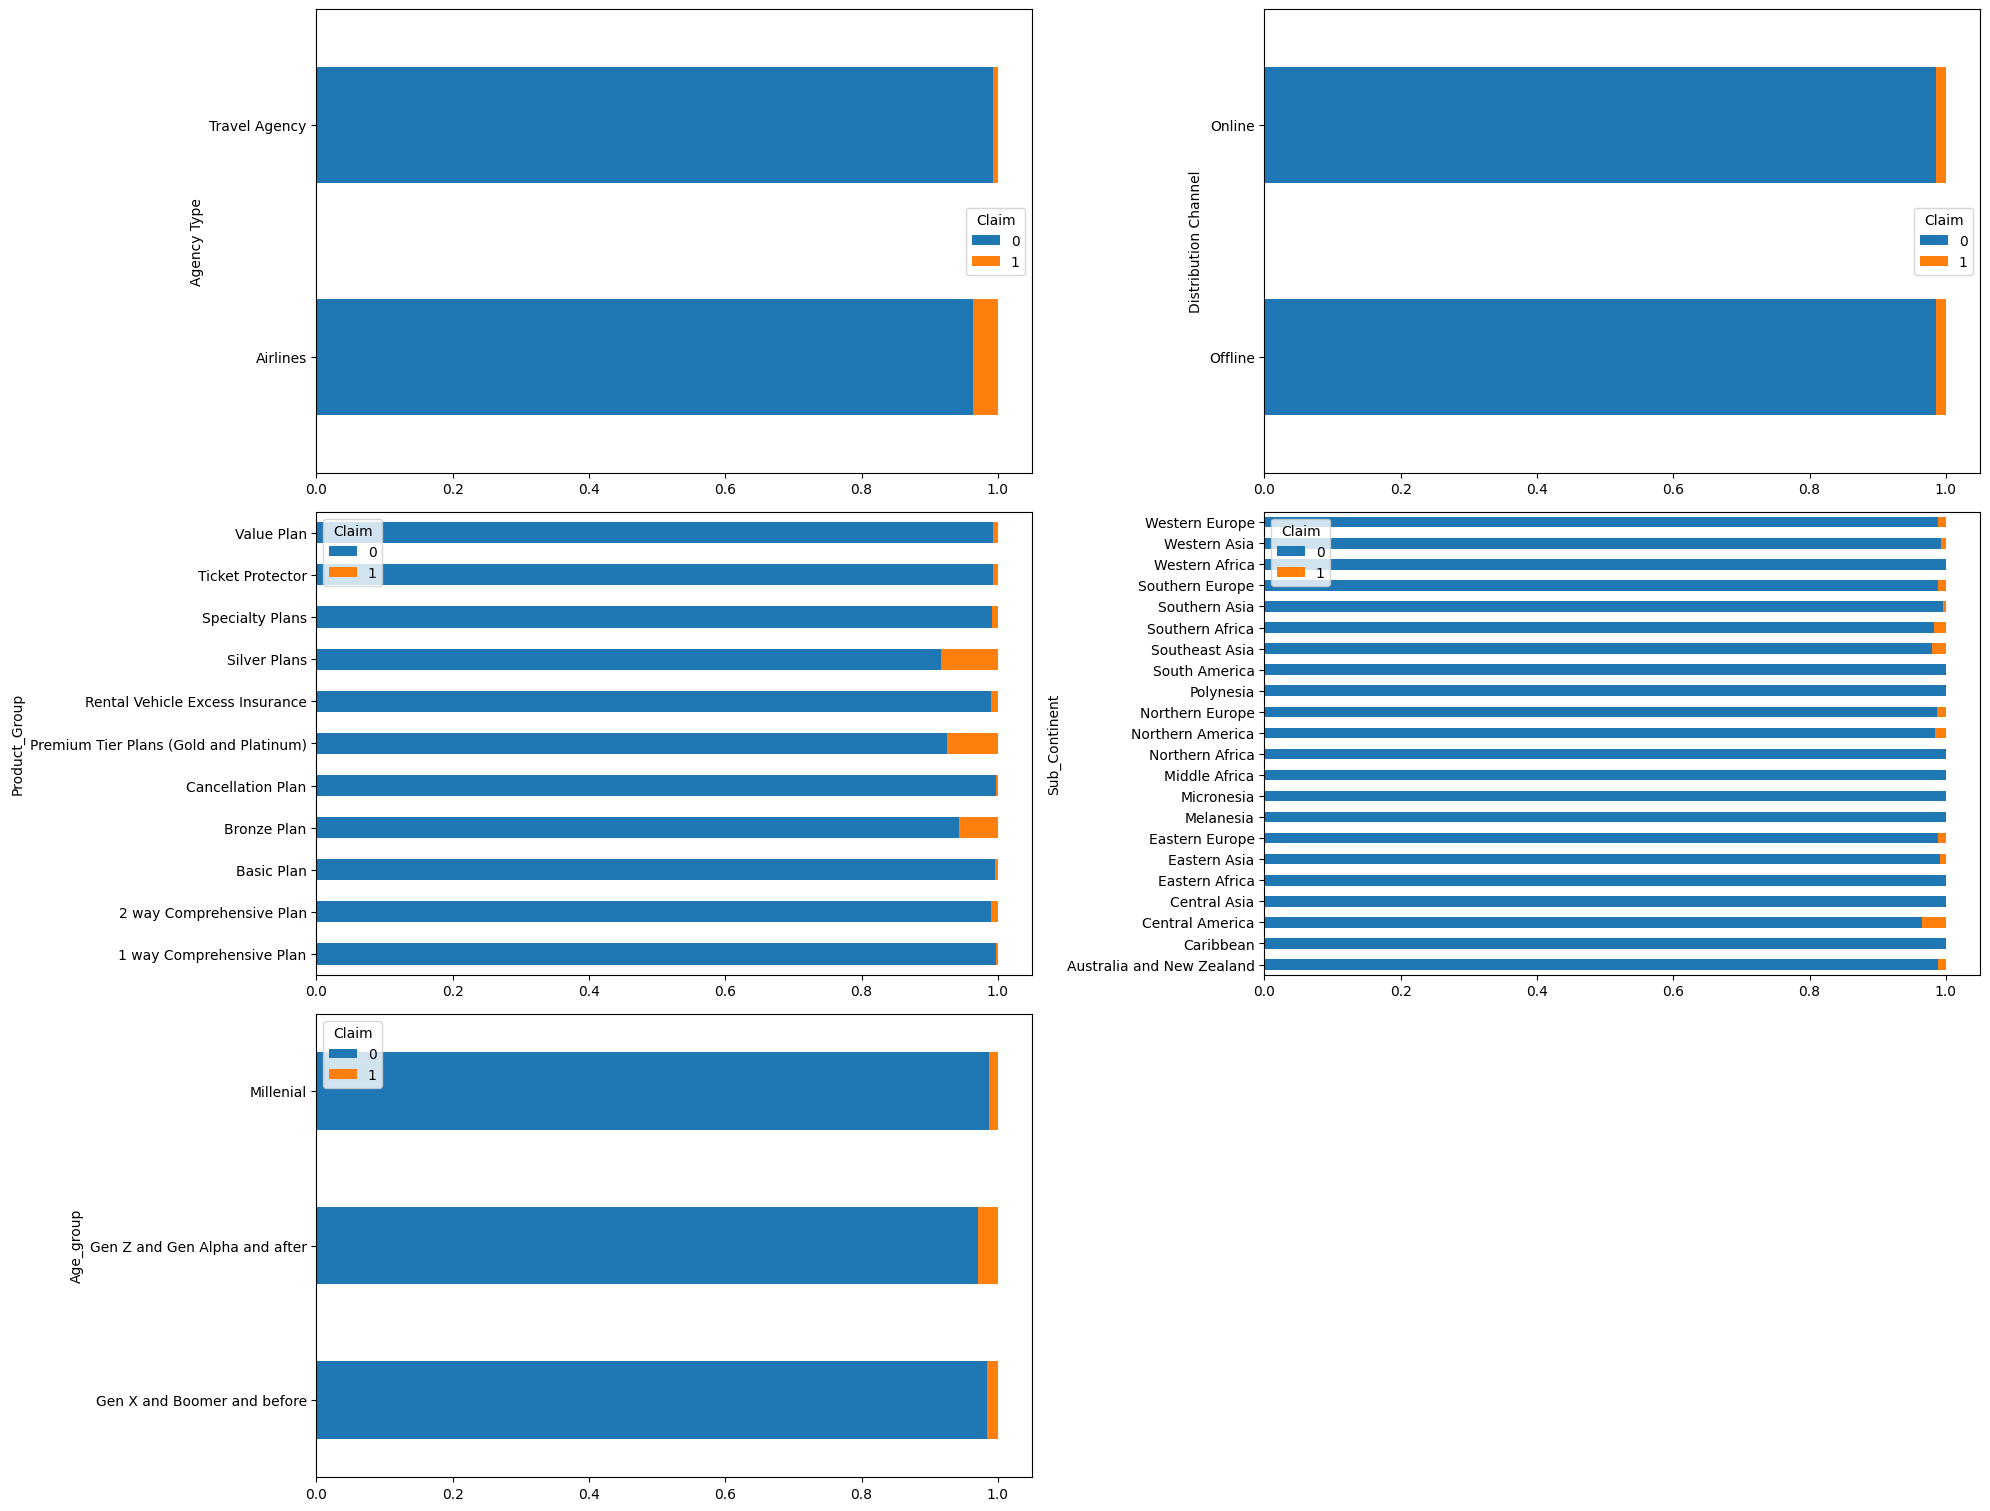

In [724]:
count = 0
fig = plt.figure(figsize=(20,20))

for i in df_ins_cleaned.drop(columns=['Claim','Duration','Net Sales','Commision (in value)', 'is_mandatory_travel_insurance', 'net_revenue']).columns:
    count +=1
    ax= plt.subplot(4,2,count)
    pd.crosstab(df_ins_cleaned[i],df_ins_cleaned['Claim'],normalize=0).plot(kind='barh',stacked=True,ax=ax)
    fig.tight_layout()

plt.show()

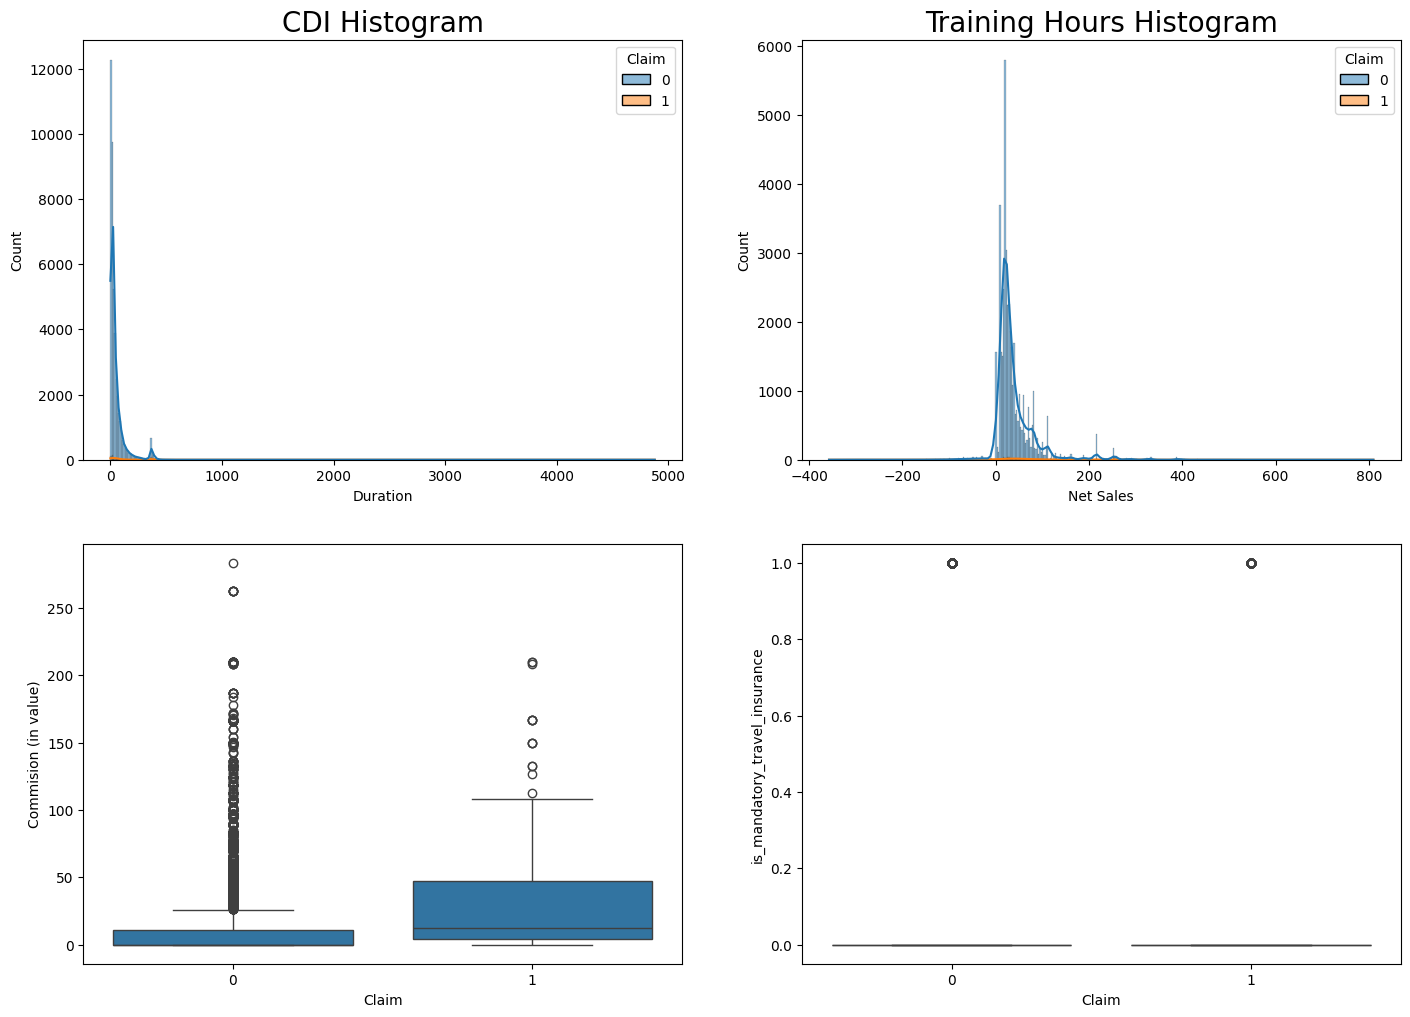

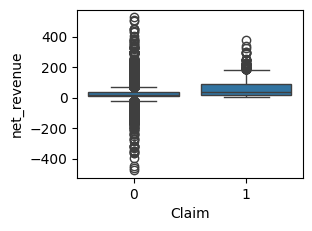

In [725]:
plt.figure(figsize=(17,12))

plt.subplot(221)
sns.histplot(data=df_ins_cleaned,x='Duration',hue='Claim',kde=True)
plt.title('CDI Histogram',fontsize=20)

plt.subplot(222)
sns.histplot(data=df_ins_cleaned,x='Net Sales',hue='Claim',kde=True)
plt.title('Training Hours Histogram',fontsize=20)

plt.subplot(223)
sns.boxplot(data=df_ins_cleaned,y='Commision (in value)', x='Claim')

plt.subplot(224)
sns.boxplot(data=df_ins_cleaned,y='is_mandatory_travel_insurance', x='Claim')
plt.show()

plt.subplot(224)
sns.boxplot(data=df_ins_cleaned,y='net_revenue', x='Claim')
plt.show()

Visualisasi dari seberapa ekstrim imbalanced data yang dimiliki dapat dilihat dari proporsi claim pada feature-feature di atas, di mana 90%+ pemegang asuransi tidak meng-klaim asuransi yang mereka miliki.

In [726]:
testing = pd.DataFrame(preprocessor_transformer.fit_transform(x_train),columns=preprocessor_transformer.get_feature_names_out())
testing.head()

,onehot encode__Agency Type_Travel Agency,onehot encode__Distribution Channel_Online,onehot encode__Age_group_Gen Z and Gen Alpha and after,onehot encode__Age_group_Millenial,binary encode__Product_Group_0,binary encode__Product_Group_1,binary encode__Product_Group_2,binary encode__Product_Group_3,binary encode__Sub_Continent_0,binary encode__Sub_Continent_1,binary encode__Sub_Continent_2,binary encode__Sub_Continent_3,binary encode__Sub_Continent_4,numerical__Duration,numerical__Net Sales,numerical__Commision (in value),numerical__is_mandatory_travel_insurance
11041,1.0,1.0,0.0,1.0,0,0,0,1,0,0,0,0,1,3,20.00,0.00,0.0
27336,0.0,1.0,0.0,0.0,0,0,1,0,0,0,0,0,1,16,1.93,0.54,0.0
30332,1.0,1.0,0.0,1.0,0,0,1,1,0,0,0,1,0,2,10.00,0.00,0.0
17529,1.0,1.0,0.0,1.0,0,1,0,0,0,0,0,0,1,7,39.60,23.76,0.0
44125,1.0,1.0,0.0,1.0,0,0,1,1,0,0,0,0,1,3,16.00,0.00,0.0


## Models Evaluation

### Model benchmark: Using K-fold

In [ ]:
models = [pipeline_logreg, pipeline_knn, pipeline_dt, pipeline_rf, pipeline_xgb, pipeline_lgbm]
score=[]
rata=[]
std=[]

for i in models:
    skfold=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    estimator=Pipeline([
        # ('preprocess', preprocessor_transformer_knn_logreg),
        ('model', i)])
    model_cv=cross_val_score(
        estimator,
        x_train,
        y_train,
        cv=skfold,
        scoring='average_precision')
    score.append(model_cv)
    rata.append(model_cv.mean())
    std.append(model_cv.std())
    
pd.DataFrame({'model': ['Logistic Regression', 'KNN', 'Decision Tree', 'RandomForest', 'XGBoost', 'LightGBM'],'mean pr_auc':rata,'sdev':std}).set_index('model').sort_values(by='mean pr_auc',ascending=False)

,mean pr_auc,sdev
model,,
LightGBM,0.076328,0.009436
Logistic Regression,0.070761,0.007832
XGBoost,0.060247,0.006374
RandomForest,0.042663,0.007517
KNN,0.029282,0.005604
Decision Tree,0.023723,0.002912


Hasil benchmark berdasarkan rata-rata dari PR AUC dengan defauld hyperparameter dari cross validation sebanyak 5x menunjukkan model dengan performa yang _terbaik_ yaitu LightGBM. Akan tetapi, bila dilihat dari score rata-rata PR AUC nya, terlihat bahwa score tersebut sangat jauh dari score 1, karena penyebab dari imbalanced data yang relatif ekstrim.

### Model benchmark: Test Dataset

In [728]:
models =  [pipeline_logreg, pipeline_knn, pipeline_dt, pipeline_rf, pipeline_xgb, pipeline_lgbm]
score_pr_auc = []

def y_pred_func(i):
    estimator=Pipeline([
        # ('preprocess', preprocessor_transformer),
        ('model',i)])
    x_train,
    x_test
    
    estimator.fit(x_train,y_train)
    return(estimator,estimator.predict(x_test),x_test)

for i,j in zip(models, ['Logistic Regression', 'KNN', 'Decision Tree', 'RandomForest', 'XGBoost', 'LightGBM']):
    estimator,y_pred,x_test = y_pred_func(i)
    y_predict_proba = estimator.predict_proba(x_test)[:,1]
    score_pr_auc.append(average_precision_score(y_test,y_predict_proba))
    print(j,'\n', classification_report(y_test,y_pred))
    
pd.DataFrame({'model':['Logistic Regression', 'KNN', 'Decision Tree', 'RandomForest', 'XGBoost', 'LightGBM'],
             'pr_auc score':score_pr_auc}).set_index('model').sort_values(by='pr_auc score',ascending=False)

Logistic Regression 
               precision    recall  f1-score   support

           0       0.99      0.81      0.89      8731
           1       0.05      0.71      0.10       135

    accuracy                           0.80      8866
   macro avg       0.52      0.76      0.50      8866
weighted avg       0.98      0.80      0.88      8866

KNN 
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      8731
           1       0.00      0.00      0.00       135

    accuracy                           0.98      8866
   macro avg       0.49      0.50      0.50      8866
weighted avg       0.97      0.98      0.98      8866

Decision Tree 
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      8731
           1       0.09      0.19      0.13       135

    accuracy                           0.96      8866
   macro avg       0.54      0.58      0.55      8866
weighted avg       0.97      0

,pr_auc score
model,
LightGBM,0.082244
Logistic Regression,0.069577
XGBoost,0.066871
RandomForest,0.058303
Decision Tree,0.031093
KNN,0.029055


Hasil dari recall pada positive class dari logistic regression memberikan sedikit performa yang lebih baik dibandingkan LightGBM, dengan mengorbankan precision pasda positive class nya. Alhasil, PR AUC score yang ada pada logistic regression jauh di bawah LightGBM.   

Karena itulah, dari hasil tersebut, LightGBM akan dipilih sebagai model untuk proses lebih lanjut karena metrik PR AUC nya yang lebih baik

### Hyperparameter Tuning

In [ ]:
estimator = Pipeline([
    ('preprocess', preprocessor_transformer),
    # ('ros', RandomOverSampler(random_state=42)),
    # ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    # ('scaler_2', StandardScaler()),
    # ('clean_cols', CleanColumnNames()),
    ('model', LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1))
])

In [ ]:
hyperparam_space=[{
    'model__max_bin': [255, 275, 300, 230],
    'model__num_leaves':[31, 21, 41, 51],
    'model__min_data_in_leaf': [20, 15, 30, 40],
    'model__num_iterations':[100,75, 125, 150],
    'model__learning_rate': [0.1, 0.075, 0.125, 0.05],
    'model__random_state': [42]
}]

In [ ]:
grid = RandomizedSearchCV(estimator, n_jobs=-1, param_distributions= hyperparam_space, scoring='average_precision', cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), verbose=3)

In [733]:
grid.fit(x_train,y_train)
print(grid.best_score_)
print(grid.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 2/5] END model__learning_rate=0.075, model__max_bin=300, model__min_data_in_leaf=15, model__num_iterations=125, model__num_leaves=21, model__random_state=42;, score=0.093 total time=   3.5s
[CV 4/5] END model__learning_rate=0.075, model__max_bin=300, model__min_data_in_leaf=15, model__num_iterations=125, model__num_leaves=21, model__random_state=42;, score=0.088 total time=   3.5s
[CV 1/5] END model__learning_rate=0.075, model__max_bin=300, model__min_data_in_leaf=15, model__num_iterations=125, model__num_leaves=21, model__random_state=42;, score=0.079 total time=   3.5s
[CV 5/5] END model__learning_rate=0.075, model__max_bin=300, model__min_data_in_leaf=15, model__num_iterations=125, model__num_leaves=21, model__random_state=42;, score=0.067 total time=   4.0s
[CV 3/5] END model__learning_rate=0.075, model__max_bin=300, model__min_data_in_leaf=15, model__num_iterations=125, model__num_leaves=21, model__random_state=42;, 

In [734]:
best_model = grid.best_estimator_
best_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('clean_cols', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot encode', ...), ('binary encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a stri

In [735]:
estimator.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('clean_cols', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot encode', ...), ('binary encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a stri

In [736]:
y_pred_default = estimator.predict(x_test)
y_pred_proba_default = estimator.predict_proba(x_test)
y_pred_tuned = best_model.predict(x_test)
y_pred_proba_tuned = best_model.predict_proba(x_test)

pr_auc_default = average_precision_score(y_test, y_pred_proba_default[:,1])
pr_auc_tuned = average_precision_score(y_test, y_pred_proba_tuned[:,1])

print('PR AUC Score Default LGBM : ', pr_auc_default)
print('PR AUC Score Tuned LGBM : ', pr_auc_tuned)

PR AUC Score Default LGBM :  0.08224350641375601
PR AUC Score Tuned LGBM :  0.07681435611666448


In [738]:
report_default = classification_report(y_test, y_pred_default)
report_tuned = classification_report(y_test, y_pred_tuned)

print('Classification Report Default LGBM : \n', report_default)
print('Classification Report Tuned LGBM : \n', report_tuned)

Classification Report Default LGBM : 
               precision    recall  f1-score   support

           0       0.99      0.86      0.92      8731
           1       0.06      0.59      0.11       135

    accuracy                           0.86      8866
   macro avg       0.53      0.73      0.52      8866
weighted avg       0.98      0.86      0.91      8866

Classification Report Tuned LGBM : 
               precision    recall  f1-score   support

           0       0.99      0.81      0.89      8731
           1       0.05      0.70      0.10       135

    accuracy                           0.81      8866
   macro avg       0.52      0.75      0.50      8866
weighted avg       0.98      0.81      0.88      8866



### Feature Importances

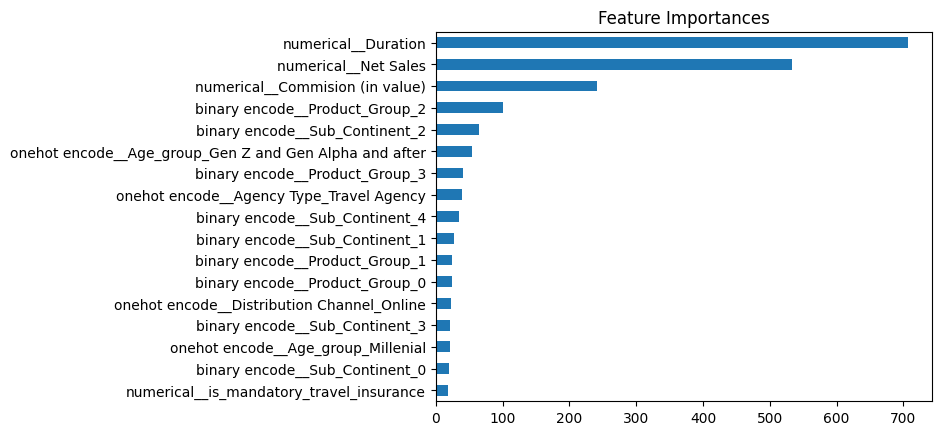

In [739]:
coef1 = pd.Series(best_model['model'].feature_importances_, preprocessor_transformer.get_feature_names_out()).sort_values(ascending = True)
coef1.plot(kind='barh', title='Feature Importances')
plt.show()

Berdasarkan visualisasi dari bar chart untuk feature importance, dapat dilihat bahwa durasi, net sales, dan commission menjadi top 3 features yang paling berpengaruh terhadap hasil dari model Machine Learning yang telah dibuat

## Conclusion

In [740]:
print('PR AUC Score Tuned LGBM : ', pr_auc_tuned)
print('Classification Report Tuned LGBM : \n', report_tuned)

PR AUC Score Tuned LGBM :  0.07681435611666448
Classification Report Tuned LGBM : 
               precision    recall  f1-score   support

           0       0.99      0.81      0.89      8731
           1       0.05      0.70      0.10       135

    accuracy                           0.81      8866
   macro avg       0.52      0.75      0.50      8866
weighted avg       0.98      0.81      0.88      8866



In [741]:
df_ins_cleaned["Net Sales"].mean()

np.float64(40.55094815917705)

In [742]:
df_ins_cleaned["Commision (in value)"].mean()

np.float64(9.707691526800218)

In [743]:
df_ins_cleaned["net_revenue"].mean()

np.float64(30.84325663237683)

Pertimbangan saya untuk lanjut menggunakan LightGBM _after hyperparameter tuning_ daripada _default hyperparameter_ karena, kita masih dapat meningkatkan score recall pada positive class meskipun tidak sesignifikan itu, tanpa mengorbankan score precision pada positive class. 

Maka dari itu, interpretasi yang bisa kita dapatkan dari output machine learning menggunakan model LightGBM ini adalah:
- Dari 100 orang yang meng-klaim asuransi nya di REAL LIFE, 70 (70%) dari mereka dapat diprediksi oleh model tersebut (true positive), sementara 30 orang (30%) sisanya adalah orang-orang yang diprediksi tidak meng-klaim asuransi tetapi turns out meng-klaim asuransi (false negative).
- Sementara itu, mengukur dari seberapa presisi model yang telah dibuat. Dari 100 orang yang DIPREDIKSI meng-klaim asuransi, hanya 6 orang (6%) yang ternyata memang meng-klaim (true positive), dan sisanya 94 orang tidak meng-klaim (false positive).

Dengan menggunakan model machine learning ini, berdasarkan cost-benefit analysis, kita akan mendapatkan keuntungan dari yang semula:
- Dari proporsi 1.53% dari jumlah orang yang meng-klaim asuransi, dengan score PR AUC sebesar 7.96% ini dapat kita simpulkan bahwa model machine learning kita dapat memprediksi 5x lebih baik (7.96% dibagi 1.53%) daripada bila kita tidak menggunakan model machine learning tersebut sama sekali.

**Parameter asumsi biaya-biaya:**
- Total Pelanggan: 8.866 orang (sesuai test set)
- Total Klaim Aktual: 135 orang (1,53%) before model
- Average Premi (Net Sales): USD 40.55 per orang
- Average Commission fee: USD 9.7 per agency
- Average Pendapatan (Net Revenue): USD 30.85 per orang
- Kerugian (Biaya Klaim): USD 240 per klaim (USD 40 premium x 6) (https://www.squaremouth.com/press-room/travel-insurance-claims-paid-out-6x-policy-premium-in-2023)


### Cost-Benefit & Liquidity Risk Analysis
| Metrik Operasional & Finansial | Before Model (Tanpa Prediksi) | After Model (Tuned LGBM) |
| :--- | :--- | :--- |
| **Total Pelanggan Dilayani (Test Set)** | 8,866 orang | 8,866 orang |
| **Pendapatan Bersih (Net Revenue)** | USD 273,072.80 <br>*(8,866 orang × USD 30.80)* | USD 273,072.80 <br>*(8,866 orang × USD 30.80)* |
| **Total Beban Klaim Aktual** | - USD 32,400.00 <br>*(135 kasus aktual × USD 240)* | - USD 32,400.00 <br>*(135 kasus aktual × USD 240)* |
| **PROFIT BERSIH (P&L)** | **USD 240,672.80** | **USD 240,672.80** |
| ----------------------------------------- | ----------------------------- | ----------------------------- |
| **METRIK MITIGASI RISIKO LIKUIDITAS** | ⚠️ **High Risk** (Blind) | ✅ **Managed Risk** (Prepared) |
| **Dana Klaim yang Berhasil Disiapkan** | **USD 0** | **USD 22,800.00** <br>*(True Positives: 95 × USD 240)* |
| **Risiko Kejutan Klaim (Gagal Antisipasi)**| **USD 32,400.00** <br>*(135 kasus)* | **USD 9,600.00** <br>*(40 kasus)* |
| **Status Kesiapan Budget** | 0% Siap <br>*(Terdampak Penuh)* | **70% Siap** <br>*(Risiko Terkontrol)* |

Jadi, paling tidak dengan model ini, meskipun score PR AUC nya terbilang kecil dan precision nya tidak begitu baik, tetapi mengingat data orang yang klaim sangat minoritas (imbalanced), hasil ini sudah sangat baik dan dapat memitigasi resiko gagal prediksi dengan lebih baik dibandingkan tidak implementasi model.   

Another thing yang bisa kita lakukan untuk memitigasi risiko liquiditas, kita juga menerapkan _dynamic pricing_ premium kepada customers yang berpotensi melakukan klaim asuransi berdasarkan model di atas (95 dari True Positive dan 1,659 False Positive).

## Recommendation

Model ini sangat bisa untuk diperbaiki lagi dari segi presisi, recall dan juga PR AUC nya saat kita memiliki lebih banyak data dari orang orang yang klaim asuransi agar model dapat di-train kembali, _potentially_ dengan model lain juga.

Berdasarkan feature importance yang ada, beberapa feature yang mungkin bisa ditambahkan pada lain waktu untuk meng-improve model adalah bisa dengan feature yang berkaitan dengan business financial domain nya.

## Save Model

In [745]:
import pickle

saved_model = 'best_model_prediction_for_claimed_insurance.pkl'

with open(saved_model, 'wb') as file:
    pickle.dump(best_model, file)

print("Saved successfully!")

Saved successfully!
